# SARIMA on Latest R1 Features Dataset

This notebook builds a SARIMA workflow on top of the latest `features_YYYYMMDD_HHMMSS.csv` file in `data/processed/`.

The goal is not to produce a final production model yet, but to create a transparent baseline that lets you study:

- hourly seasonality in delay
- differences across delay definitions (`delay_type_1`, `delay_type_2`, and a combined `type1&2` view)
- whether a simple SARIMA model can capture the trend/seasonality you observed in the EDA

The notebook works on the processed dataset after filtering out rows with missing `direction`, because that is the working subset used in the main EDA notebook.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

In [2]:
# Resolve paths whether the notebook is launched from `EDA/` or the repo root.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        path
        for path in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", path.name)
    )
    if not candidates:
        raise FileNotFoundError("No timestamped features CSV found in data/processed/.")
    return candidates[-1]


def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [3]:
# Load the latest features file and parse timestamps.
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

for col in ["planned_arrival_dt", "actual_arrival_dt", "hour_trunc", "service_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_model = df[df["direction"].notna()].copy()

print(f"Loaded features file: {features_path.name}")
print(f"Original rows: {len(df):,}")
print(f"Rows with non-missing direction: {len(df_model):,}")
print(f"Date range: {df_model['service_date'].min().date()} -> {df_model['service_date'].max().date()}")
print("\nDay type counts (rows):")
display(df_model["day_type"].value_counts())

Loaded features file: features_20260506_224510.csv
Original rows: 6,090
Rows with non-missing direction: 5,747
Date range: 2026-03-15 -> 2026-05-04

Day type counts (rows):


day_type
weekend    3508
workday    2174
holiday      65
Name: count, dtype: int64

### Interpretation

On the current latest file, the filtered modeling table keeps `5747` rows out of `6090`, so the missing-direction removal is relatively small.

This notebook now compares three univariate targets built from the same filtered modeling table: `delay_type_1`, `delay_type_2`, and a combined `type1&2` series defined as the row-wise mean of the two delay definitions.

The latest build now also includes hourly weather features (`temperature`, `precipitation`, `windspeed`, `weathercode`, `cloudcover`), although this notebook still starts from a pure univariate SARIMA baseline.

## 1. Build Hourly Time Series

SARIMA expects a univariate time series indexed at a regular frequency.

Here we aggregate the processed train-station rows into **hourly average delay series** for three target variants:

- `type_1_only`: hourly mean of `delay_type_1`
- `type_2_only`: hourly mean of `delay_type_2`
- `type_1_and_2`: hourly mean of a combined row-wise average of `delay_type_1` and `delay_type_2`

The combined `type1&2` target keeps the SARIMA setup univariate while still reflecting both delay definitions in one series.

In [4]:
def build_hourly_delay_series(frame: pd.DataFrame, target_col: str) -> pd.Series:
    subset = frame.dropna(subset=["hour_trunc", target_col]).copy()
    hourly = (
        subset.groupby("hour_trunc")[target_col]
        .mean()
        .sort_index()
    )

    full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="H")
    hourly = hourly.reindex(full_index)
    hourly = hourly.interpolate(method="time").ffill().bfill()
    hourly.index.name = "timestamp"
    return hourly


df_model["delay_type_1_2_mean"] = df_model[["delay_type_1", "delay_type_2"]].mean(axis=1)

target_specs = {
    "type_1_only": "delay_type_1",
    "type_2_only": "delay_type_2",
    "type_1_and_2": "delay_type_1_2_mean",
}

target_notes = {
    "type_1_only": "Type 1 = last actual arrival - first planned arrival.",
    "type_2_only": "Type 2 = last actual arrival - last planned arrival.",
    "type_1_and_2": "Type 1&2 = row-wise mean of Type 1 and Type 2.",
}

series_map = {
    label: build_hourly_delay_series(df_model, target_col)
    for label, target_col in target_specs.items()
}

series_summary = pd.DataFrame({
    "target_variant": list(target_specs.keys()),
    "target_column": list(target_specs.values()),
    "n_hours": [len(series_map[label]) for label in target_specs],
})
display(series_summary)

/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_66085/683432986.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="H")
/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_66085/683432986.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="H")
/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_66085/683432986.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="H")


,target_variant,target_column,n_hours
0,type_1_only,delay_type_1,1179
1,type_2_only,delay_type_2,1179
2,type_1_and_2,delay_type_1_2_mean,1179


## 2. Visualize the Hourly Series

Before fitting SARIMA, it is useful to inspect the aggregated series directly. This lets you compare how the hourly structure changes across the three delay-target variants.

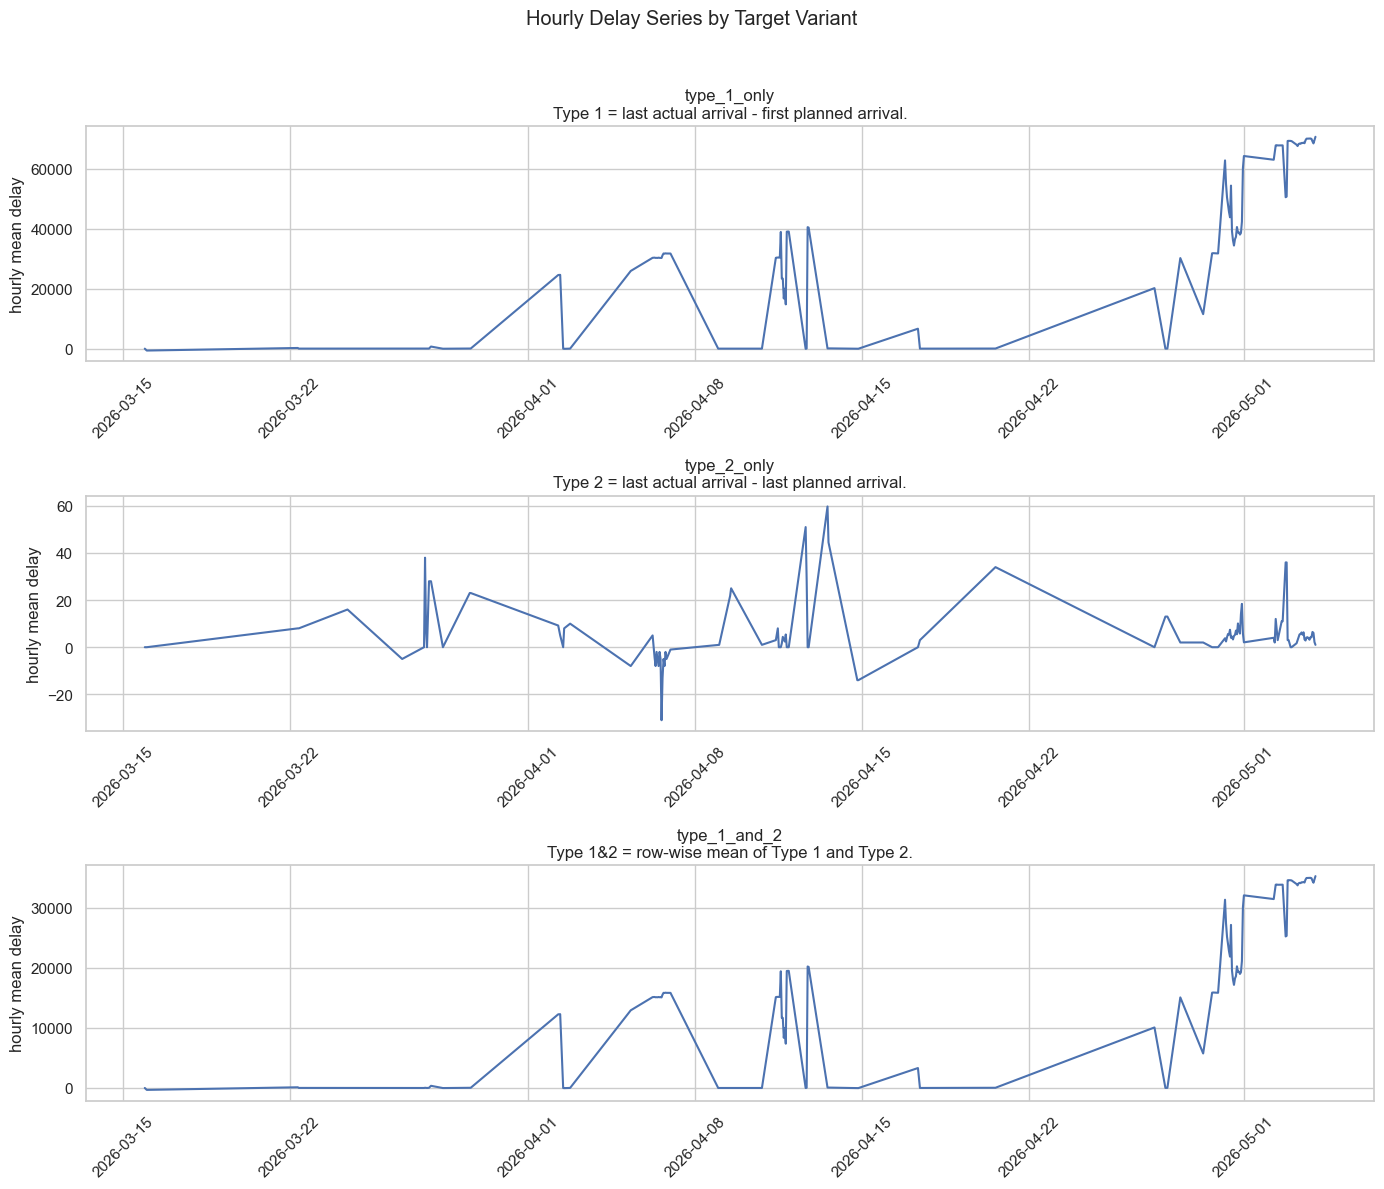

In [5]:
fig, axes = plt.subplots(len(series_map), 1, figsize=(14, 4 * len(series_map)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (label, series) in zip(axes, series_map.items()):
    ax.plot(series.index, series.values, color="#4C72B0")
    ax.set_title(f"{label}\n{target_notes[label]}")
    ax.set_ylabel("hourly mean delay")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Hourly Delay Series by Target Variant", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 3. Mean Hour-of-Day Seasonality

This reproduces the seasonality pattern in a way that is useful for model design: average delay by hour of day for each target variant.

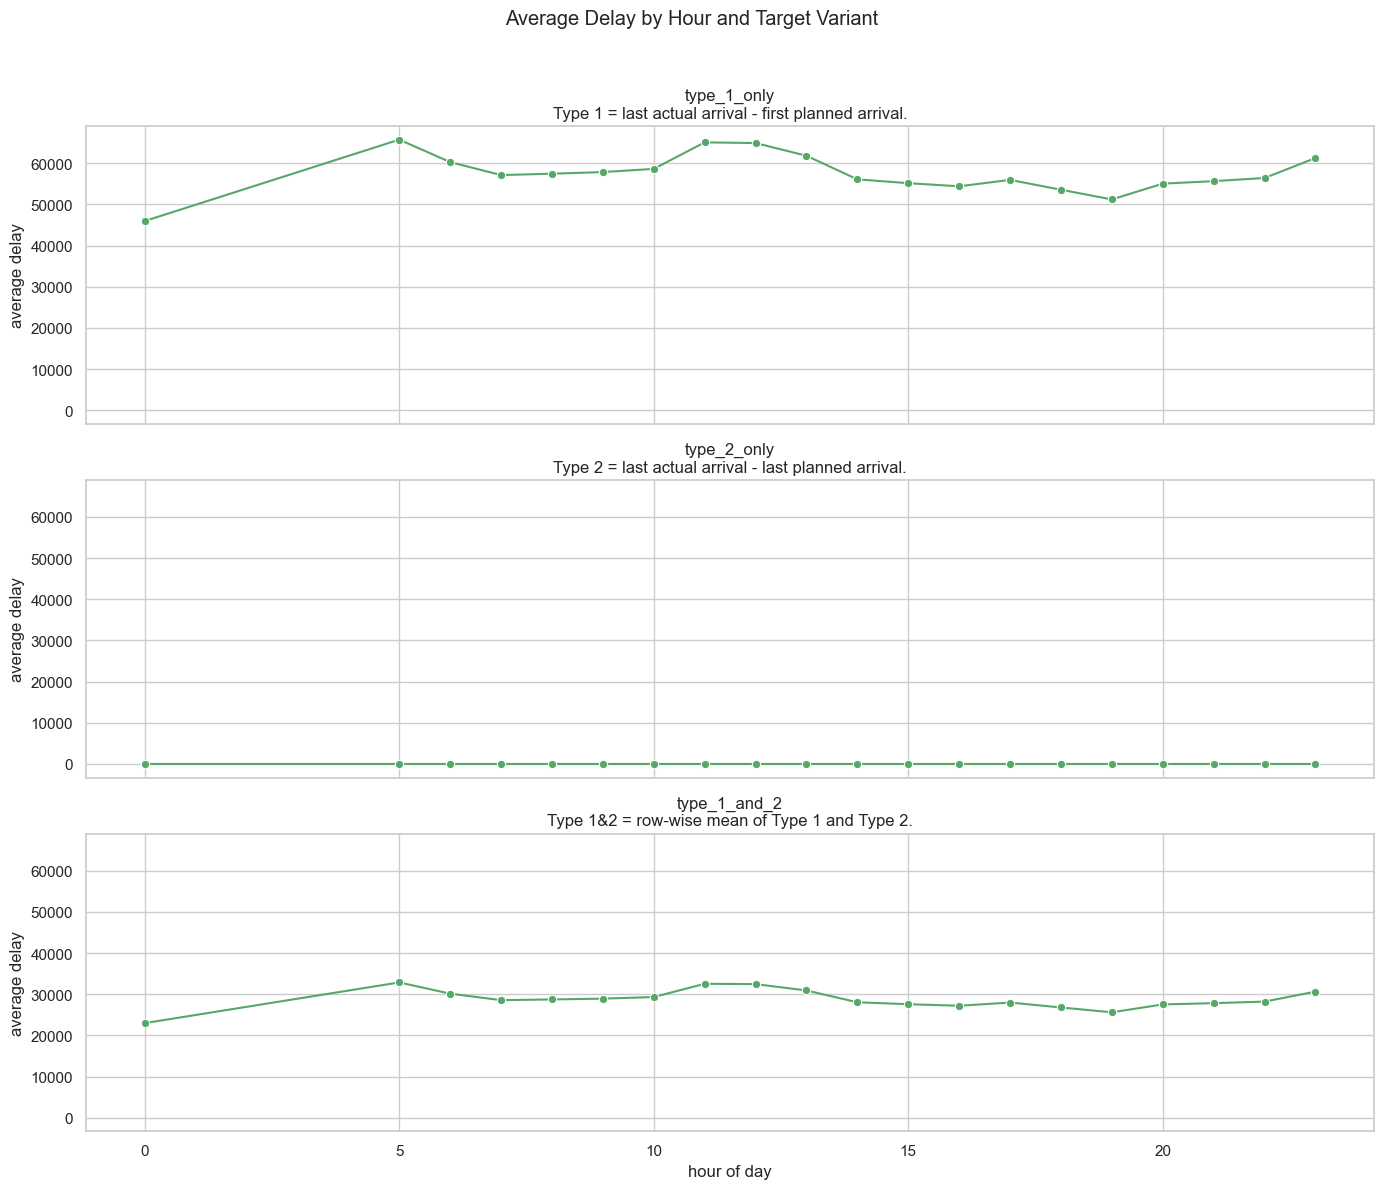

In [6]:
seasonality = pd.concat(
    [
        df_model.groupby("hour")[target_col]
        .mean()
        .reset_index(name="avg_delay")
        .assign(target_variant=label)
        for label, target_col in target_specs.items()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(len(target_specs), 1, figsize=(14, 4 * len(target_specs)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, label in zip(axes, target_specs):
    subset = seasonality[seasonality["target_variant"] == label]
    sns.lineplot(data=subset, x="hour", y="avg_delay", marker="o", ax=ax, color="#55A868")
    ax.set_title(f"{label}\n{target_notes[label]}")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("average delay")

plt.suptitle("Average Delay by Hour and Target Variant", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### Interpretation

The delay-definition comparison shows whether the daily hourly pattern is stable across the two raw delay measures or changes materially when the target definition changes.

If `delay_type_1` and `delay_type_2` produce very similar hourly shapes, the modeling conclusions should be relatively insensitive to the delay definition. If the combined `type1&2` view smooths clear differences between them, that is a sign the two definitions are capturing meaningfully different behavior.

## 4. Delay Variability by Hour of Day

Mean profiles alone can hide whether some hours are much more volatile than others.

These boxplots show the distribution of delays at each hour of day for each target variant, which makes it easier to spot wider spread, skewness, and outliers.

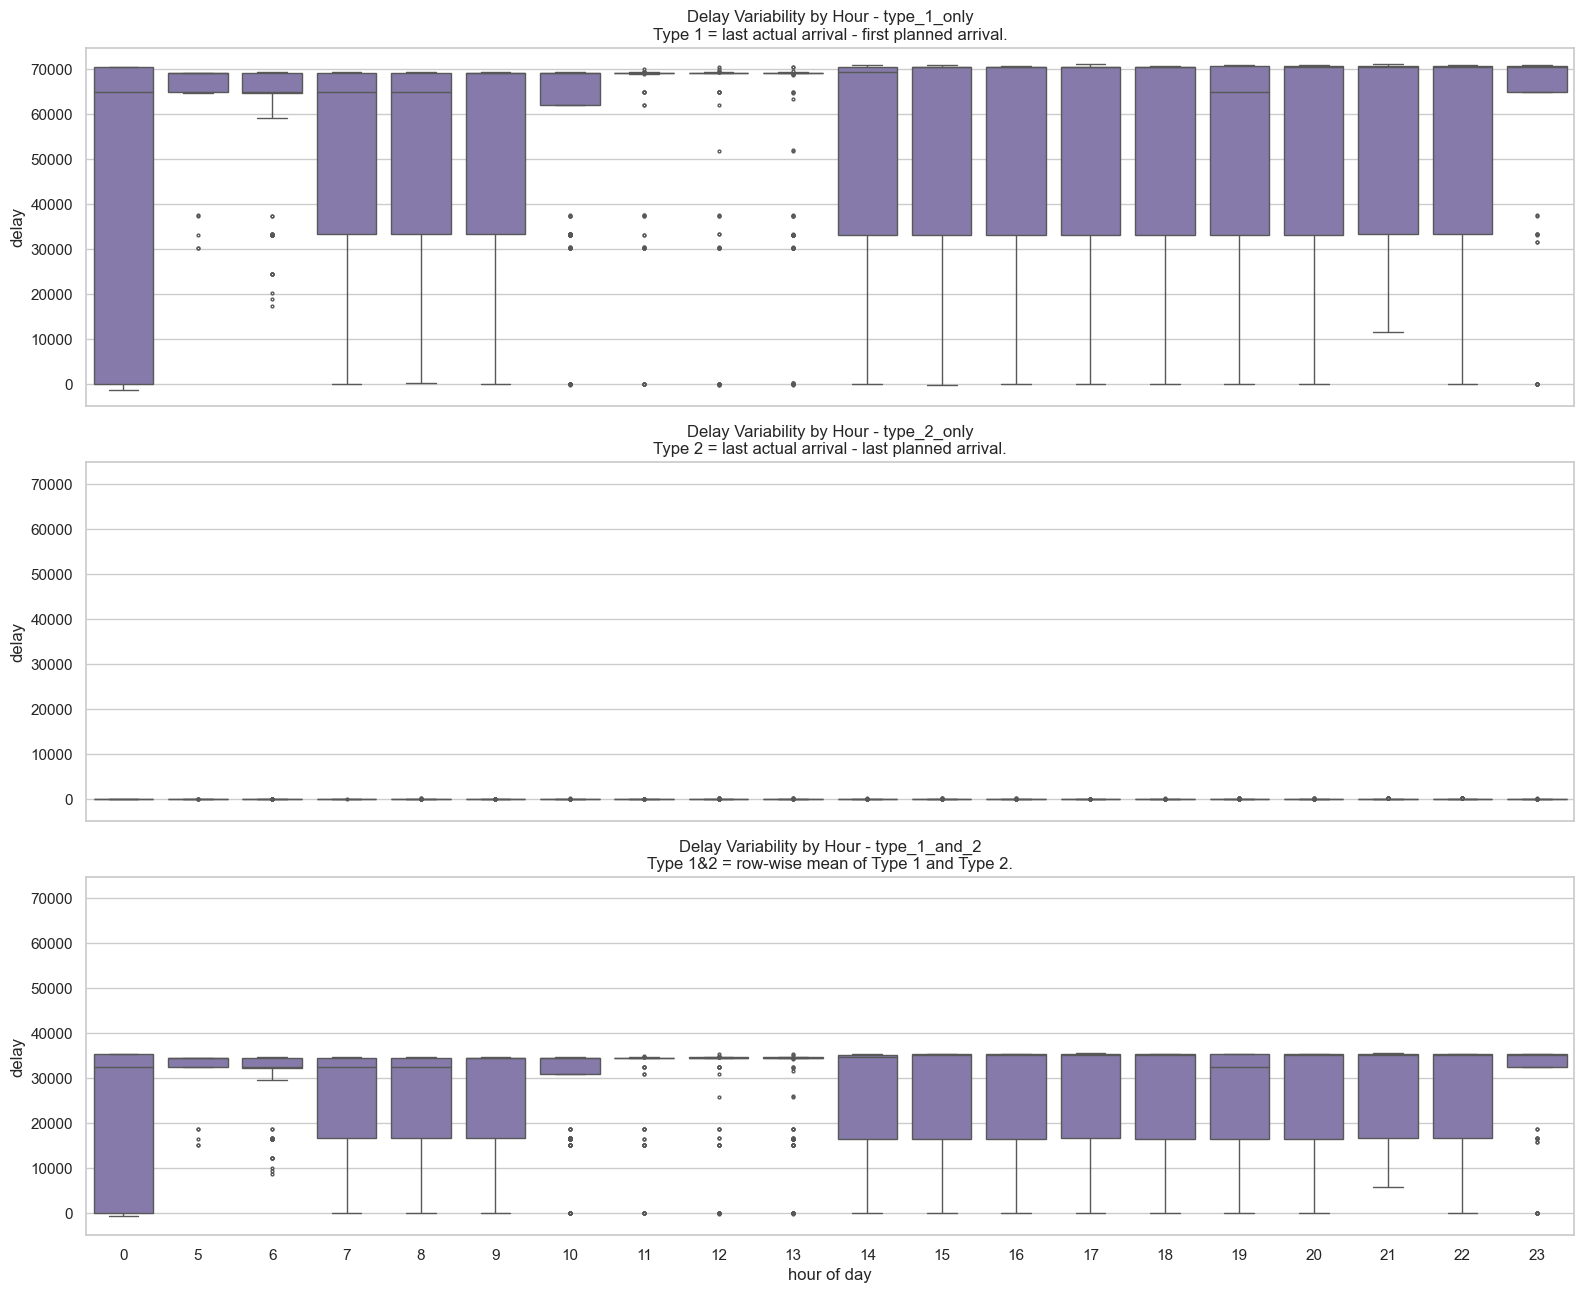

In [7]:
variability_df = pd.concat(
    [
        df_model[["hour", target_col]]
        .rename(columns={target_col: "delay_value"})
        .assign(target_variant=label)
        for label, target_col in target_specs.items()
    ],
    ignore_index=True,
).dropna(subset=["hour", "delay_value"])

fig, axes = plt.subplots(len(target_specs), 1, figsize=(16, 4.5 * len(target_specs)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, label in zip(axes, target_specs):
    subset = variability_df[variability_df["target_variant"] == label]
    sns.boxplot(data=subset, x="hour", y="delay_value", ax=ax, color="#8172B2", fliersize=2)
    ax.set_title(f"Delay Variability by Hour - {label}\n{target_notes[label]}")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("delay")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 5. ACF and PACF Diagnostics

For an hourly series, a natural seasonal period to try is `24`, corresponding to daily repetition. The ACF/PACF plots help you sanity-check whether that assumption is plausible.

We inspect ACF/PACF for each target variant so the SARIMA baseline is comparable across delay definitions.

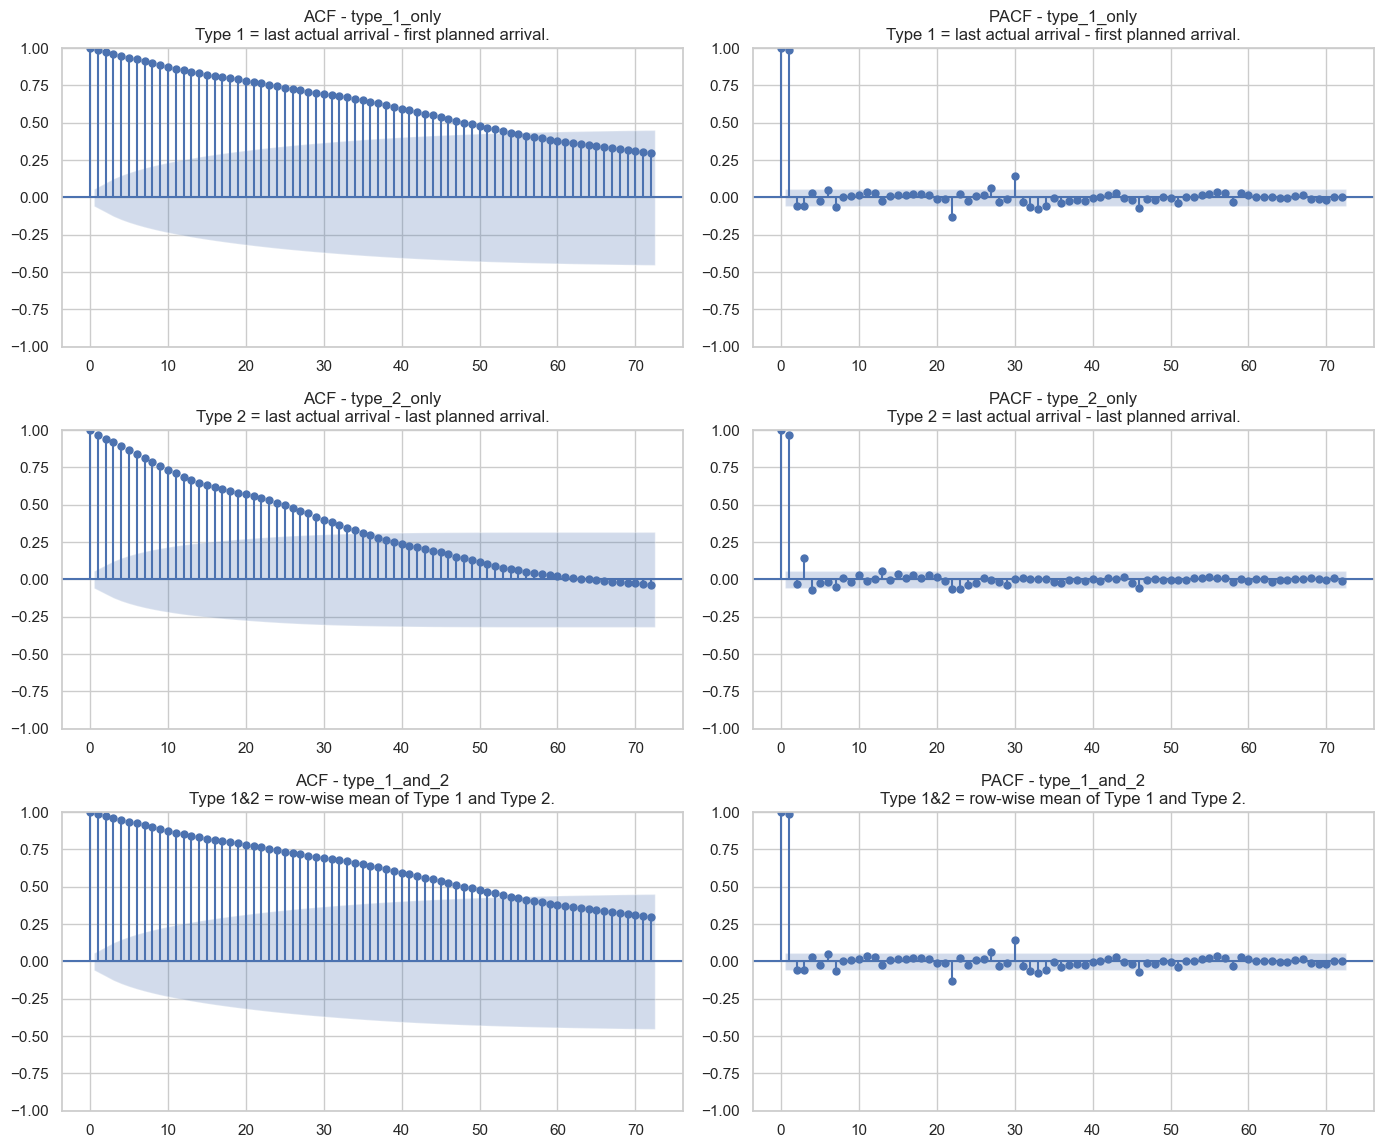

In [8]:
fig, axes = plt.subplots(len(series_map), 2, figsize=(14, 4 * len(series_map)))
axes = np.atleast_2d(axes)

for row_idx, (label, series) in enumerate(series_map.items()):
    plot_acf(series, lags=72, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"ACF - {label}\n{target_notes[label]}")
    plot_pacf(series, lags=72, ax=axes[row_idx, 1], method="ywm")
    axes[row_idx, 1].set_title(f"PACF - {label}\n{target_notes[label]}")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 6. Train/Test Split

We keep the last few days as a holdout set. For an hourly seasonal model, a holdout of 72 hours (3 days) is a reasonable starting point.

In [9]:
FORECAST_HORIZON = 72
SEASONAL_PERIOD = 24


def train_test_split_series(series: pd.Series, horizon: int = 72):
    train = series.iloc[:-horizon].copy()
    test = series.iloc[-horizon:].copy()
    return train, test


train_test_splits = {
    label: train_test_split_series(series, FORECAST_HORIZON)
    for label, series in series_map.items()
}

for label, (train, test) in train_test_splits.items():
    print(f"{label} train size: {len(train)} | test size: {len(test)}")

type_1_only train size: 1107 | test size: 72
type_2_only train size: 1107 | test size: 72
type_1_and_2 train size: 1107 | test size: 72


## 7. Fit Baseline SARIMA Models

We start with a conservative baseline specification:

- non-seasonal order: `(1, 0, 1)`
- seasonal order: `(1, 0, 1, 24)`

This is not guaranteed to be optimal, but it is a reasonable first model when the EDA suggests a daily hourly pattern.

In [10]:
def fit_sarima(series: pd.Series, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24)):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False)
    return result


sarima_results = {
    label: fit_sarima(train, order=(1, 0, 1), seasonal_order=(1, 0, 1, SEASONAL_PERIOD))
    for label, (train, _) in train_test_splits.items()
}

for label, result in sarima_results.items():
    print(f"\n=== {label} ===")
    print(result.summary())


=== type_1_only ===
                                     SARIMAX Results                                      
Dep. Variable:                       delay_type_1   No. Observations:                 1107
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -9735.494
Date:                            Fri, 15 May 2026   AIC                          19480.988
Time:                                    14:21:47   BIC                          19505.917
Sample:                                03-15-2026   HQIC                         19490.427
                                     - 05-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9992      0.003    329.617      0.000       0.993       1.005
ma.L1         

## 8. Forecast on Holdout

We now forecast the holdout period and compare predictions against the observed hourly mean delay series.

In [11]:
def forecast_and_evaluate(result, train: pd.Series, test: pd.Series, label: str):
    forecast = result.get_forecast(steps=len(test))
    pred_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    metrics = pd.DataFrame({
        "series": [label],
        "mae": [mae(test, pred_mean)],
        "rmse": [rmse(test, pred_mean)],
    })

    return pred_mean, conf_int, metrics


forecast_outputs = {
    label: forecast_and_evaluate(sarima_results[label], train, test, label)
    for label, (train, test) in train_test_splits.items()
}

display(
    pd.concat(
        [metrics for _, _, metrics in forecast_outputs.values()],
        ignore_index=True,
    )
)

,series,mae,rmse
0,type_1_only,5287.360856,6722.829633
1,type_2_only,4.048645,7.758115
2,type_1_and_2,2606.577903,3319.257706


### Interpretation

This comparison shows which delay definition is easiest for the baseline SARIMA to track on the holdout window.

Use the MAE and RMSE table above to compare:

- `type_1_only`
- `type_2_only`
- `type_1_and_2`

Lower errors indicate a target definition whose hourly dynamics are more regular under this simple daily seasonal specification.

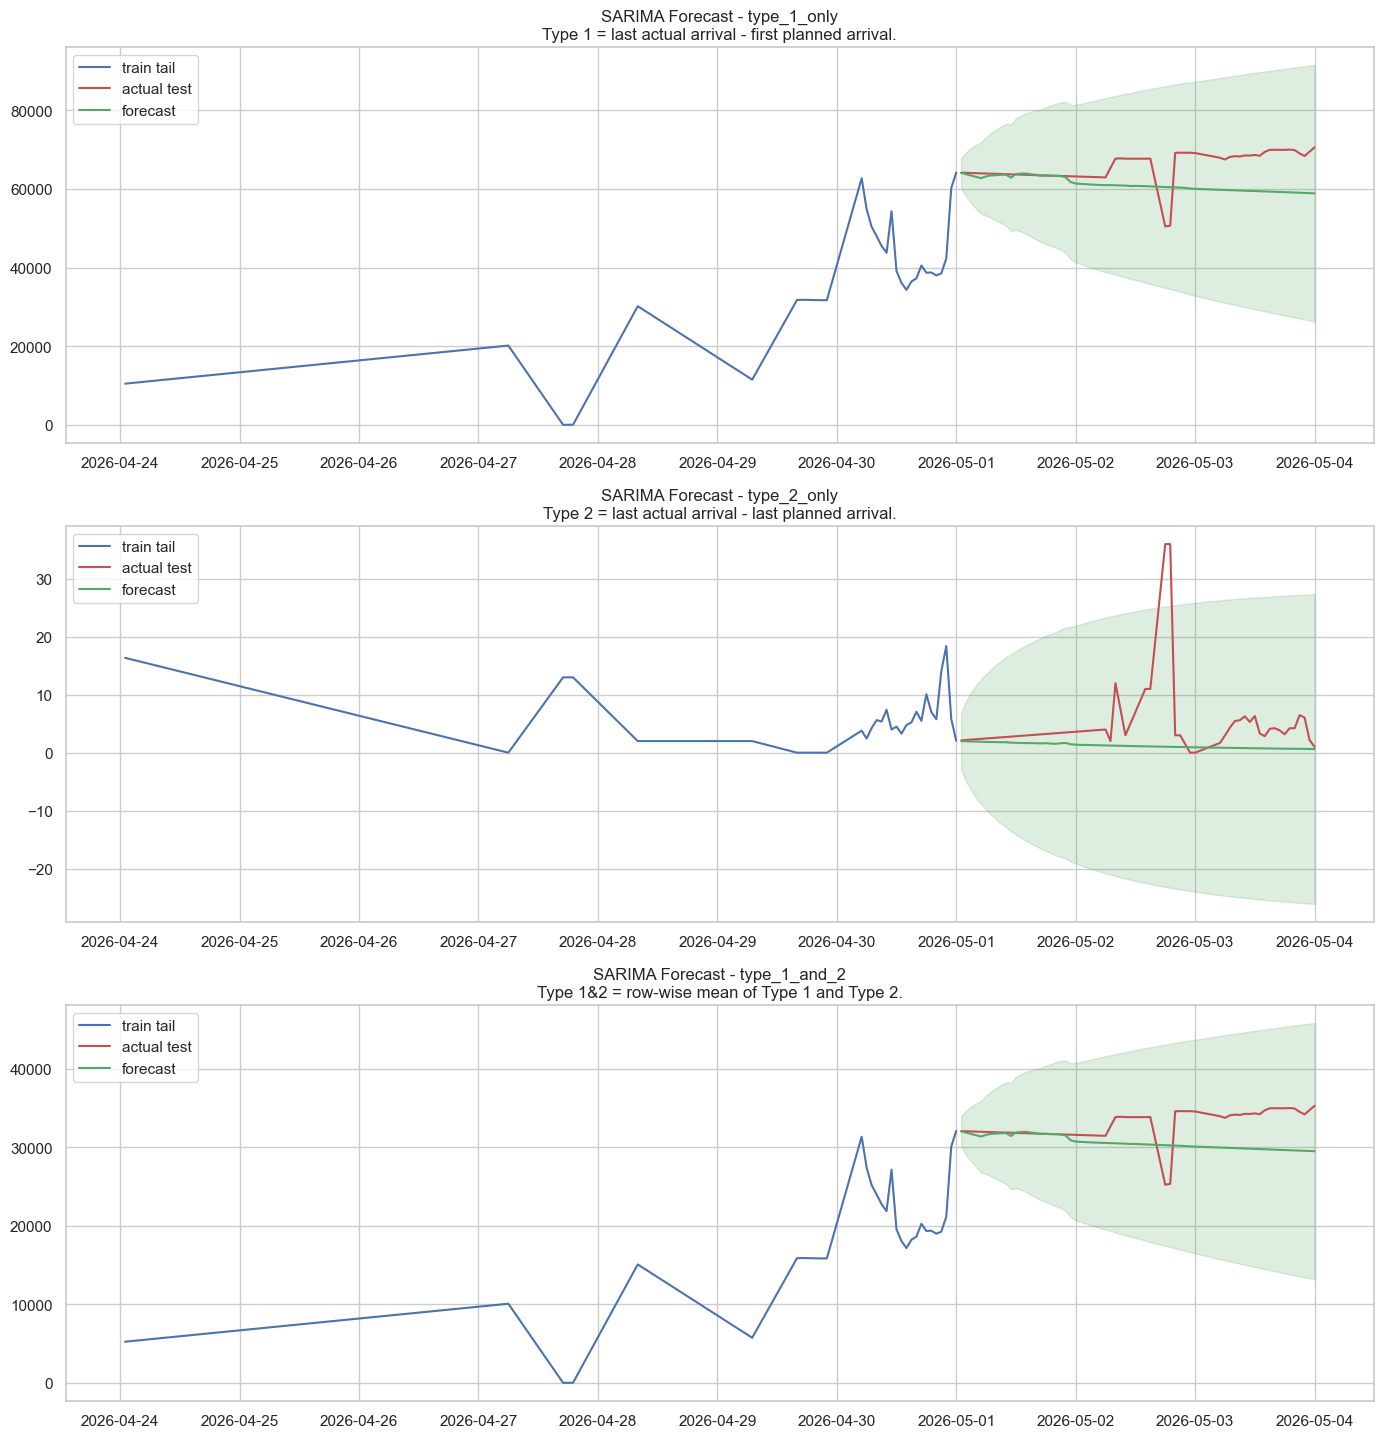

In [12]:
fig, axes = plt.subplots(len(forecast_outputs), 1, figsize=(14, 5 * len(forecast_outputs)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (label, (pred, ci, _)) in zip(axes, forecast_outputs.items()):
    train, test = train_test_splits[label]
    ax.plot(train.index[-7*24:], train.iloc[-7*24:], label="train tail", color="#4C72B0")
    ax.plot(test.index, test, label="actual test", color="#C44E52")
    ax.plot(pred.index, pred, label="forecast", color="#55A868")
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#55A868", alpha=0.2)
    ax.set_title(f"SARIMA Forecast - {label}\n{target_notes[label]}")
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 9. Residual Diagnostics

Residual diagnostics help you judge whether the model has captured most of the structure or whether strong autocorrelation remains.

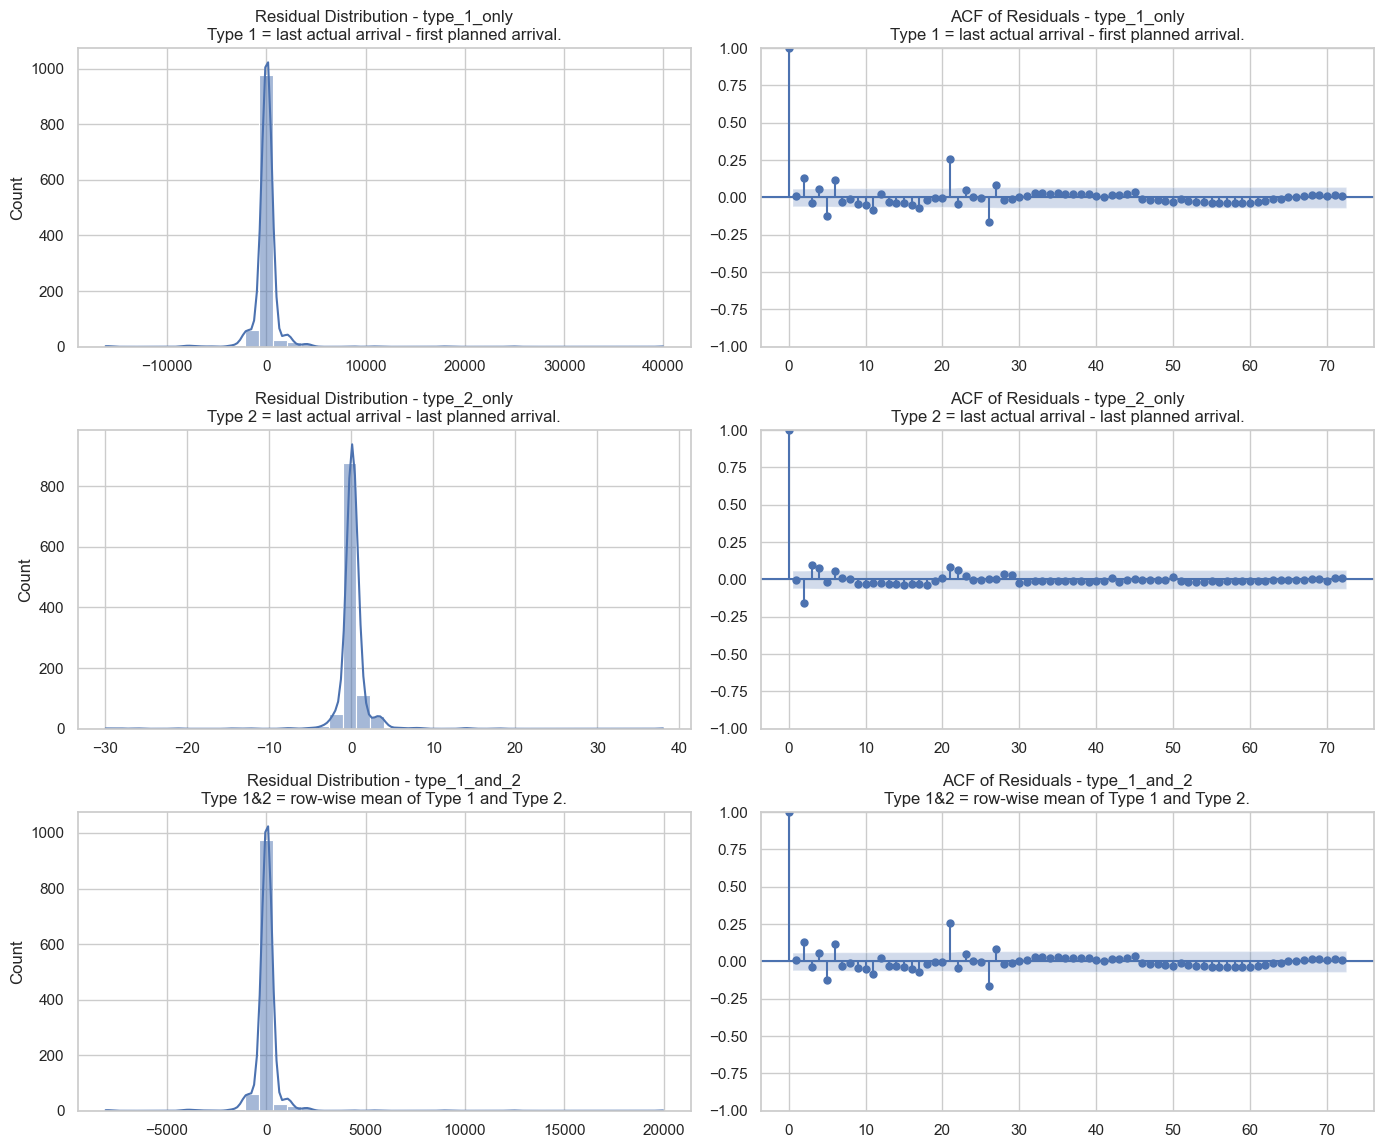

In [13]:
fig, axes = plt.subplots(len(sarima_results), 2, figsize=(14, 4 * len(sarima_results)))
axes = np.atleast_2d(axes)

for row_idx, (label, result) in enumerate(sarima_results.items()):
    resid = result.resid.dropna()
    sns.histplot(resid, bins=40, kde=True, ax=axes[row_idx, 0], color="#4C72B0")
    axes[row_idx, 0].set_title(f"Residual Distribution - {label}\n{target_notes[label]}")
    plot_acf(resid, lags=72, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"ACF of Residuals - {label}\n{target_notes[label]}")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 10. Optional Extensions

Natural next steps after this baseline:

- tune `(p, d, q)` and `(P, D, Q, 24)` more systematically
- compare tuned specifications separately for `delay_type_1`, `delay_type_2`, and the combined `type1&2` target
- add exogenous regressors via `SARIMAX`, for example:
  - `is_holiday`
  - `is_weekend`
  - weather variables now available in the feature table (`temperature`, `precipitation`, `windspeed`, `weathercode`, `cloudcover`)
  - station-level or direction-level aggregates
- compare hourly mean delay against other targets, for example hourly median delay
- compare SARIMA against simpler baselines such as seasonal naive forecasts